<a href="https://colab.research.google.com/github/alfredoluis848/matriz-de-confusao-analise-de-metricas/blob/main/matriz_de_confus%C3%A3o.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from tensorflow.keras import datasets, layers, models
import matplotlib.pyplot as plt
import tensorflow as tf

import numpy as np

import seaborn as sns

import pandas as pd

In [ ]:
tf.__version__

'2.20.0'

In [ ]:
%load_ext tensorboard

In [ ]:
logdir='log'

In [ ]:
(train_images, train_labels), (test_images, test_labels) = datasets.mnist.load_data()

train_images = train_images.reshape((60000, 28, 28, 1))
test_images = test_images.reshape((10000, 28, 28, 1))

train_images, test_images = train_images / 255.0, test_images / 255.0

classes=[0,1,2,3,4,5,6,7,8,9]

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
model = models.Sequential()
model.add(layers.Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(64, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(64, (3, 3), activation='relu'))

model.add(layers.Flatten())
model.add(layers.Dense(64, activation='relu'))
model.add(layers.Dense(10, activation='softmax'))


/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
tensorboard_callback = tf.keras.callbacks.TensorBoard(logdir, histogram_freq=1)

In [ ]:
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

model.fit(x=train_images,
            y=train_labels,
            epochs=5,
            validation_data=(test_images, test_labels))

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 15s 5ms/step - accuracy: 0.9546 - loss: 0.1474 - val_accuracy: 0.9862 - val_loss: 0.0447
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.9857 - loss: 0.0461 - val_accuracy: 0.9878 - val_loss: 0.0387
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9897 - loss: 0.0340 - val_accuracy: 0.9904 - val_loss: 0.0291
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.9920 - loss: 0.0258 - val_accuracy: 0.9910 - val_loss: 0.0291
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9933 - loss: 0.0208 - val_accuracy: 0.9903 - val_loss: 0.0320


In [ ]:
y_true=test_labels
y_pred=np.argmax(model.predict(test_images), axis=-1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


In [ ]:
classes=[0,1,2,3,4,5,6,7,8,9]

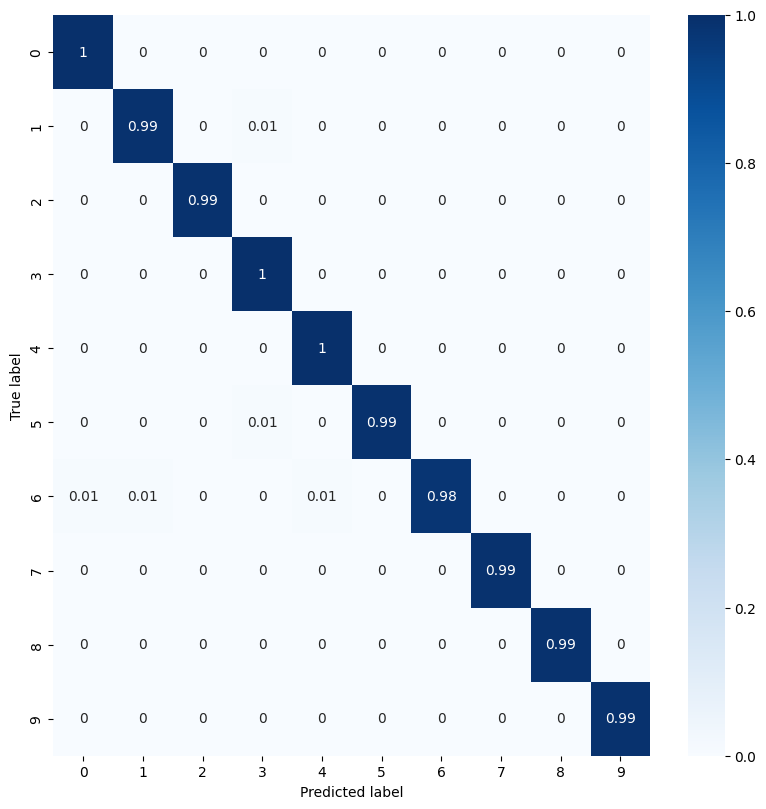

In [ ]:
con_mat = tf.math.confusion_matrix(labels=y_true, predictions=y_pred).numpy()
con_mat_norm = np.around(con_mat.astype('float') / con_mat.sum(axis=1)[:, np.newaxis], decimals=2)

con_mat_df = pd.DataFrame(con_mat_norm,
                     index = classes,
                     columns = classes)

figure = plt.figure(figsize=(8, 8))
sns.heatmap(con_mat_df, annot=True,cmap=plt.cm.Blues)
plt.tight_layout()
plt.ylabel('True label')
plt.xlabel('Predicted label')
plt.show()

In [ ]:
print(con_mat)

[[ 979    0    0    0    0    0    0    1    0    0]
 [   0 1126    1    6    0    0    0    0    2    0]
 [   0    0 1026    0    2    0    0    4    0    0]
 [   0    0    1 1006    0    1    0    1    1    0]
 [   0    0    0    0  978    0    0    1    0    3]
 [   1    0    0    9    0  879    2    1    0    0]
 [   7    5    1    0    7    2  935    0    1    0]
 [   0    4    4    1    0    1    0 1015    1    2]
 [   4    1    1    0    1    1    0    1  964    1]
 [   0    0    0    1    3    3    0    4    3  995]]


In [ ]:
classe_positiva = 5
vp = con_mat[classe_positiva, classe_positiva]
print(vp)

879


In [ ]:
fn = con_mat[classe_positiva, :].sum() - vp

fp = con_mat[:, classe_positiva].sum() - vp

print("FN:", fn)
print("FP:", fp)

FN: 13
FP: 8


In [ ]:
total = con_mat.sum()

vn = total - (vp + fn + fp)

print("Total:", total)
print("VN:", vn)

Total: 10000
VN: 9100


In [ ]:
sensibilidade = vp / (vp + fn)

print(f"Sensibilidade: {sensibilidade:.4f}")
print(f"Sensibilidade: {sensibilidade:.2%}")

Sensibilidade: 0.9854
Sensibilidade: 98.54%


In [ ]:
especificidade = vn / (vn + fp)

print(f"Especificidade: {especificidade:.4f}")
print(f"Especificidade: {especificidade:.2%}")

Especificidade: 0.9991
Especificidade: 99.91%


In [ ]:
precisao = vp / (vp + fp)

print(f"Precisão: {precisao:.4f}")
print(f"Precisão: {precisao:.2%}")

Precisão: 0.9910
Precisão: 99.10%


In [ ]:
acuracia = (vp + vn) / total

print(f"Acurácia: {acuracia:.4f}")
print(f"Acurácia: {acuracia:.2%}")

Acurácia: 0.9979
Acurácia: 99.79%


In [ ]:
f_score = 2 * (precisao * sensibilidade) / (precisao + sensibilidade)

print(f"F-score: {f_score:.4f}")
print(f"F-score: {f_score:.2%}")

F-score: 0.9882
F-score: 98.82%


In [ ]:
print(f"VP: {vp}")
print(f"VN: {vn}")
print(f"FP: {fp}")
print(f"FN: {fn}")

print(f"\nSensibilidade: {sensibilidade:.2%}")
print(f"Especificidade: {especificidade:.2%}")
print(f"Acurácia: {acuracia:.2%}")
print(f"Precisão: {precisao:.2%}")
print(f"F-score: {f_score:.2%}")

VP: 879
VN: 9100
FP: 8
FN: 13

Sensibilidade: 98.54%
Especificidade: 99.91%
Acurácia: 99.79%
Precisão: 99.10%
F-score: 98.82%


In [ ]:
model1 = models.Sequential()
model1.add(layers.Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)))
model1.add(layers.MaxPooling2D((2, 2)))
model1.add(layers.Conv2D(64, (3, 3), activation='relu'))
model1.add(layers.MaxPooling2D((2, 2)))
model1.add(layers.Conv2D(64, (3, 3), activation='relu'))

model1.add(layers.Flatten())
model1.add(layers.Dense(64, activation='relu'))
model1.add(layers.Dense(10, activation='softmax'))

model1.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
file_writer = tf.summary.create_file_writer(logdir + '/cm')

def log_confusion_matrix(epoch, logs):
  # Use the model to predict the values from the validation dataset.
  test_pred = model1.predict_classes(test_images)

  con_mat = tf.math.confusion_matrix(labels=test_labels, predictions=test_pred).numpy()
  con_mat_norm = np.around(con_mat.astype('float') / con_mat.sum(axis=1)[:, np.newaxis], decimals=2)

  con_mat_df = pd.DataFrame(con_mat_norm,
                     index = classes,
                     columns = classes)

  figure = plt.figure(figsize=(8, 8))
  sns.heatmap(con_mat_df, annot=True,cmap=plt.cm.Blues)
  plt.tight_layout()
  plt.ylabel('True label')
  plt.xlabel('Predicted label')

  buf = io.BytesIO()
  plt.savefig(buf, format='png')

  plt.close(figure)
  buf.seek(0)
  image = tf.image.decode_png(buf.getvalue(), channels=4)

  image = tf.expand_dims(image, 0)

  # Log the confusion matrix as an image summary.
  with file_writer.as_default():
    tf.summary.image("Confusion Matrix", image, step=epoch)


logdir='logs/images'

tensorboard_callback = tf.keras.callbacks.TensorBoard(log_dir=logdir)

cm_callback = keras.callbacks.LambdaCallback(on_epoch_end=log_confusion_matrix)

In [ ]:
model1.fit(
    train_images,
    train_labels,
    epochs=5,
    verbose=0,
    callbacks=[tensorboard_callback, cm_callback],
    validation_data=(test_images, test_labels),
)

In [ ]:
# Start TensorBoard.
%tensorboard --logdir logs/images